In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

In [4]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
from keras.models import Sequential
from keras.layers import Embedding, LSTM, Dense, Dropout, Conv1D, MaxPooling1D
from keras.preprocessing.sequence import pad_sequences
from keras.optimizers import Adam
from tensorflow.keras.preprocessing.text import Tokenizer

In [5]:
df = pd.read_csv('Sentiment_Labelled_CommentsV3.csv')

In [6]:
df.head()

,UserID,Date,Comment,Cleaned_Comment_v2,textblob_score,Textblob_sentiment,vader_score,Vader_sentiment,sentiment_scores,Sentiment
0,Golden Cross Stocks,2024-12-03 19:31:55,$ILLR The U.S. #TikTok Ban is on the Horizon.....,illr u tiktok ban horizon triller positioned t...,0.214286,pos,-0.5574,neg,-0.171557,neg
1,Dominic Cardy,2024-12-05 21:37:52,Canada!\n\nBan TikTok now. Before it's too late.,canada ban tiktok late,-0.300000,neg,-0.5574,neg,-0.428700,neg
2,Scott gibboney,2024-12-06 13:41:11,Tiktok sucks but Russia is not the problem. ...,tiktok suck russia problem everything russia f...,-0.100000,neg,-0.7717,neg,-0.435850,neg
3,Dominic Cardy,2024-12-06 16:34:29,Your lack of interest in knowing the truth is ...,lack interest knowing truth problem course eve...,0.225000,pos,0.4767,pos,0.350850,pos
4,Mickey Sunshine,2024-12-06 17:35:28,"Ban it for the bad financial advice alone, let...",ban bad financial advice alone let alone anyth...,-0.350000,neg,-0.8779,neg,-0.613950,neg


In [7]:
df.shape

(9440, 10)

## 1.Sentiment Analysis Using Text Classification

### 1.1 TF-IDF + Machine Learning Models

In [8]:
X = df['Cleaned_Comment_v2']
y = df['Sentiment']

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

# Vectorization: TF-IDF
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train_tfidf)
X_test_tfidf = vectorizer.transform(X_test_tfidf)

# === Logistic Regression ===
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_tfidf, y_train_tfidf)
logreg_preds = logreg.predict(X_test_tfidf)
print("=== LogReg ===")
print(classification_report(y_test_tfidf, logreg_preds, target_names=label_encoder.classes_))

# === SVM ===
svm = SVC(kernel='linear')
svm.fit(X_train_tfidf, y_train_tfidf)
svm_preds = svm.predict(X_test_tfidf)
print("=== SVM ===")
print(classification_report(y_test_tfidf, svm_preds, target_names=label_encoder.classes_))

# === XGBoost ===
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
xgb_model.fit(X_train_tfidf, y_train_tfidf)
xgb_preds = xgb_model.predict(X_test_tfidf)
print("=== XGBoost ===")
print(classification_report(y_test_tfidf, xgb_preds, target_names=label_encoder.classes_))


=== LogReg ===
              precision    recall  f1-score   support

         neg       0.74      0.78      0.76      1130
     neutral       0.76      0.59      0.67       525
         pos       0.75      0.79      0.77      1177

    accuracy                           0.75      2832
   macro avg       0.75      0.72      0.73      2832
weighted avg       0.75      0.75      0.75      2832

=== SVM ===
              precision    recall  f1-score   support

         neg       0.75      0.76      0.75      1130
     neutral       0.70      0.72      0.71       525
         pos       0.77      0.75      0.76      1177

    accuracy                           0.75      2832
   macro avg       0.74      0.74      0.74      2832
weighted avg       0.75      0.75      0.75      2832



/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [18:21:43] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== XGBoost ===
              precision    recall  f1-score   support

         neg       0.83      0.66      0.73      1130
     neutral       0.60      0.94      0.73       525
         pos       0.79      0.75      0.77      1177

    accuracy                           0.75      2832
   macro avg       0.74      0.78      0.74      2832
weighted avg       0.77      0.75      0.75      2832



### 1.2:Word2Vec + Deep Learning Models

In [9]:
import pandas as pd
import numpy as np
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, SimpleRNN, Conv1D, MaxPooling1D, GlobalMaxPooling1D, Dense, Dropout

In [10]:
df = pd.read_csv("Sentiment_Labelled_CommentsV3.csv")
texts = df['Cleaned_Comment_v2'].astype(str).tolist()
labels = df['Sentiment'].tolist()

encoder = LabelEncoder()
y = encoder.fit_transform(labels)
y = to_categorical(y)

# Word2Vec
tokenized_texts = [text.split() for text in texts]
w2v_model = Word2Vec(sentences=tokenized_texts, vector_size=100, window=5, min_count=1, workers=4)

# Tokenizer and padding
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
padded = pad_sequences(sequences, maxlen=100)
word_index = tokenizer.word_index

# Construct the embedding_matrix for Word2Vec
embedding_matrix = np.zeros((10000, 100))
for word, i in word_index.items():
    if i < 10000 and word in w2v_model.wv:
        embedding_matrix[i] = w2v_model.wv[word]

X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(padded, y, test_size=0.2, random_state=42, stratify=y)

In [11]:
# === LSTM ===
print("\nTraining LSTM model with Word2Vec...")
model_lstm = Sequential()
model_lstm.add(Embedding(input_dim=10000, output_dim=100, weights=[embedding_matrix], input_length=100, trainable=True)) 
model_lstm.add(LSTM(64))
model_lstm.add(Dropout(0.5))
model_lstm.add(Dense(3, activation='softmax'))
model_lstm.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model_lstm.fit(X_train_dl, y_train_dl, epochs=5, batch_size=64, validation_split=0.1)
model_lstm.evaluate(X_test_dl, y_test_dl)

y_true = np.argmax(y_test_dl, axis=1)
# === LSTM Reprot ===
y_pred_lstm = np.argmax(model_lstm.predict(X_test_dl), axis=1)
print("=== LSTM ===")
print(classification_report(y_true, y_pred_lstm, target_names=encoder.classes_))


Training LSTM model with Word2Vec...
Epoch 1/5


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


107/107 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step - accuracy: 0.4464 - loss: 0.9877 - val_accuracy: 0.5503 - val_loss: 0.9185
Epoch 2/5
107/107 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - accuracy: 0.5864 - loss: 0.8526 - val_accuracy: 0.7183 - val_loss: 0.6916
Epoch 3/5
107/107 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.8447 - loss: 0.4787 - val_accuracy: 0.7526 - val_loss: 0.6189
Epoch 4/5
107/107 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - accuracy: 0.9326 - loss: 0.2381 - val_accuracy: 0.7791 - val_loss: 0.6059
Epoch 5/5
107/107 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.9653 - loss: 0.1309 - val_accuracy: 0.7725 - val_loss: 0.6476
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7799 - loss: 0.6552
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
=== LSTM ===
              precision    recall  f1-score   support

         neg       0.77      0.77      0.77       753
     neutral       0.82      0.77      0.79       350
         pos       0.77      0.79      0.78       785

    accuracy               

In [12]:
# === CNN ===
print("\nTraining CNN model with Word2Vec...")
model_cnn = Sequential()
model_cnn.add(Embedding(input_dim=10000, output_dim=100, weights=[embedding_matrix], input_length=100, trainable=True))
model_cnn.add(Conv1D(128, 5, activation='relu'))
model_cnn.add(MaxPooling1D(pool_size=2))
model_cnn.add(GlobalMaxPooling1D())
model_cnn.add(Dropout(0.5))
model_cnn.add(Dense(3, activation='softmax'))
model_cnn.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model_cnn.fit(X_train_dl, y_train_dl, epochs=5, batch_size=64, validation_split=0.1)
model_cnn.evaluate(X_test_dl, y_test_dl)

# === CNN Report ===
y_pred_cnn = np.argmax(model_cnn.predict(X_test_dl), axis=1)
print("=== CNN ===")
print(classification_report(y_true, y_pred_cnn, target_names=encoder.classes_))



Training CNN model with Word2Vec...
Epoch 1/5


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.4257 - loss: 1.0205 - val_accuracy: 0.5013 - val_loss: 0.9393
Epoch 2/5
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.5456 - loss: 0.9167 - val_accuracy: 0.6667 - val_loss: 0.7852
Epoch 3/5
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.7281 - loss: 0.6854 - val_accuracy: 0.7579 - val_loss: 0.6125
Epoch 4/5
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.8721 - loss: 0.3926 - val_accuracy: 0.7897 - val_loss: 0.5267
Epoch 5/5
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9379 - loss: 0.2222 - val_accuracy: 0.7884 - val_loss: 0.5434
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7730 - loss: 0.5562
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
=== CNN ===
              precision    recall  f1-score   support

         neg       0.72      0.83      0.77       753
     neutral       0.83      0.74      0.78       350
         pos       0.80      0.74      0.77       785

    accuracy                

In [18]:
# === RNN ===
print("\nTraining RNN model with Word2Vec...")
model_rnn = Sequential()
model_rnn.add(Embedding(input_dim=10000, output_dim=100, weights=[embedding_matrix], input_length=100, trainable=True))
model_rnn.add(SimpleRNN(64))
model_rnn.add(Dropout(0.5))
model_rnn.add(Dense(3, activation='softmax'))
model_rnn.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model_rnn.fit(X_train_dl, y_train_dl, epochs=5, batch_size=64, validation_split=0.1)
model_rnn.evaluate(X_test_dl, y_test_dl)

# === RNN Report ===
y_pred_rnn = np.argmax(model_rnn.predict(X_test_dl), axis=1)
print("=== RNN ===")
print(classification_report(y_true, y_pred_rnn, target_names=encoder.classes_))


Training RNN model with Word2Vec...
Epoch 1/5


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.4188 - loss: 1.0649 - val_accuracy: 0.4683 - val_loss: 0.9379
Epoch 2/5
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.6451 - loss: 0.8235 - val_accuracy: 0.6217 - val_loss: 0.7962
Epoch 3/5
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8834 - loss: 0.4225 - val_accuracy: 0.6746 - val_loss: 0.7538
Epoch 4/5
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9611 - loss: 0.1750 - val_accuracy: 0.6892 - val_loss: 0.8289
Epoch 5/5
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9806 - loss: 0.0953 - val_accuracy: 0.7077 - val_loss: 0.8512
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7056 - loss: 0.8006
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
=== RNN ===
              precision    recall  f1-score   support

         neg       0.68      0.72      0.70       753
     neutral       0.71      0.79      0.75       350
         pos       0.74      0.67      0.70       785

    accuracy                

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, SimpleRNN, Conv1D, MaxPooling1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report

### 1.3 Model Performance Comparison

In [19]:
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

y_true_dl = np.argmax(y_test_dl, axis=1)

# Modeal Evaluation
report_logreg = classification_report(y_test_tfidf, logreg_preds, target_names=encoder.classes_, output_dict=True)
report_svm = classification_report(y_test_tfidf, svm_preds, target_names=encoder.classes_, output_dict=True)
report_xgb = classification_report(y_test_tfidf, xgb_preds, target_names=label_encoder.classes_, output_dict=True)
report_lstm = classification_report(y_true_dl, y_pred_lstm, target_names=encoder.classes_, output_dict=True)
report_cnn = classification_report(y_true_dl, y_pred_cnn, target_names=encoder.classes_, output_dict=True)
report_rnn = classification_report(y_true_dl, y_pred_rnn, target_names=encoder.classes_, output_dict=True)

# Plotting the results
models = ['LogReg', 'SVM','XGBoost', 'LSTM', 'CNN', 'RNN']
accuracies = [
    report_logreg['accuracy'],
    report_svm['accuracy'],
    report_xgb['accuracy'],
    report_lstm['accuracy'],
    report_cnn['accuracy'],
    report_rnn['accuracy']
]
f1_scores = [
    report_logreg['macro avg']['f1-score'],
    report_svm['macro avg']['f1-score'],
    report_xgb['macro avg']['f1-score'],
    report_lstm['macro avg']['f1-score'],
    report_cnn['macro avg']['f1-score'],
    report_rnn['macro avg']['f1-score']
]



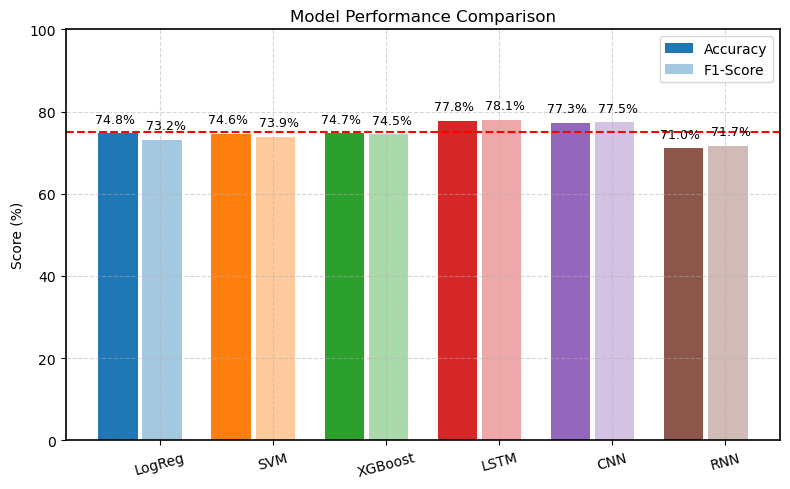

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import to_rgba

df_plot = pd.DataFrame({
    'Model': models,
    'Accuracy': [x * 100 for x in accuracies],   
    'F1-Score': [x * 100 for x in f1_scores]
})

base_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

fig, ax = plt.subplots(figsize=(8, 5))
bar_width = 0.35
index = np.arange(len(df_plot))

for i in range(len(df_plot)):
    acc_color = base_colors[i]
    f1_color = to_rgba(base_colors[i], alpha=0.4)

    # accuracy
    bar1 = ax.bar(index[i] - bar_width/2 - 0.02, df_plot['Accuracy'][i], bar_width,color=acc_color, label='Accuracy' if i == 0 else "")
    ax.text(index[i] - bar_width/2 - 0.05, df_plot['Accuracy'][i] + 2.5, f"{df_plot['Accuracy'][i]:.1f}%", ha='center', fontsize=9, color='black')

    # f1-score
    bar2 = ax.bar(index[i] + bar_width/2 + 0.02, df_plot['F1-Score'][i], bar_width,color=f1_color, label='F1-Score' if i == 0 else "")
    ax.text(index[i] + bar_width/2 + 0.05, df_plot['F1-Score'][i] + 2.5,f"{df_plot['F1-Score'][i]:.1f}%", ha='center', fontsize=9, color='black')

# Baseline line
baseline = 75
ax.axhline(y=baseline, color='red', linestyle='--', linewidth=1.5)

ax.set_ylabel('Score (%)')
ax.set_title('Model Performance Comparison')
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(df_plot['Model'], rotation=15)
ax.set_ylim(0, 100)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend()
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1.2)

plt.tight_layout()
plt.show()

## 2.Preliminary Sentiment Analysis

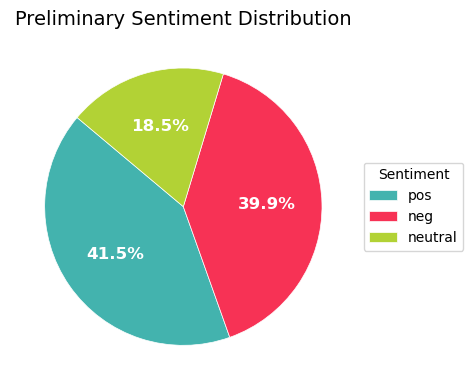

In [21]:
# Convert the 'Sentiment' column to categorical
sentiment_distribution = df['Sentiment'].value_counts(normalize=True) * 100

color_map_consistent = {
    'pos': '#43b3ae',
    'neg': '#f73255',
    'neutral': '#b2d235'
}
colors = [color_map_consistent[label] for label in sentiment_distribution.index]

fig, ax = plt.subplots(figsize=(6, 4))
wedges, texts, autotexts = ax.pie(
    sentiment_distribution,
    labels=None, 
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 0.5}
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')

ax.legend(
    wedges,
    sentiment_distribution.index,
    title="Sentiment",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)

plt.title("Preliminary Sentiment Distribution", fontsize=14, color='black')
plt.tight_layout()
plt.show()

## 2.1 Sentiment Wordclouds

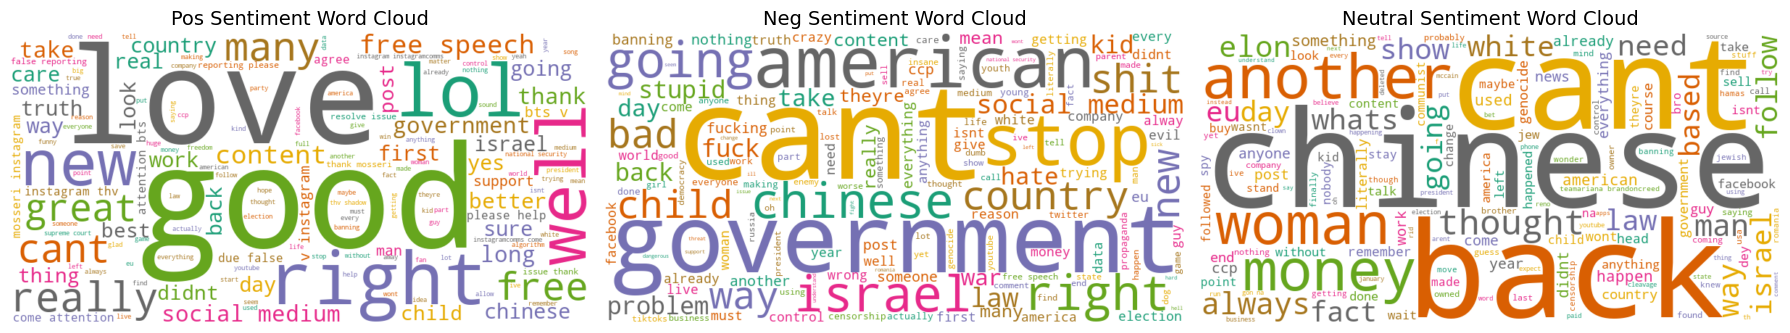

In [22]:
from wordcloud import WordCloud, STOPWORDS

sentiment_classes = ['pos', 'neg', 'neutral']

# Define custom stopwords
custom_stopwords = set(STOPWORDS)
custom_stopwords.update([
    'tiktok', 'video','time','china','trump','ban','still','banned','app','dont', 'doesnt','platform','said','let','use', 'u', 'rt', 'http', 'https','think','want','always'
    'follow', 'like', 'watch', 'get', 'amp'
])

# Generate word clouds for each sentiment class
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, sentiment in enumerate(sentiment_classes):
    text = " ".join(df[df['Sentiment'] == sentiment]['Cleaned_Comment_v2'].astype(str).tolist())
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap='Dark2',
        max_words=150,
        stopwords=custom_stopwords
    ).generate(text)

    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].axis('off')
    axes[idx].set_title(f"{sentiment.capitalize()} Sentiment Word Cloud", fontsize=14)

plt.tight_layout()
plt.show()

## 3.Fined-Grained Emotion Analysis using GoEmotions

In [23]:
import pandas as pd
from transformers import pipeline
from tqdm import tqdm 

# Load the Model
emotion_classifier = pipeline(
    "text-classification",
    model="joeddav/distilbert-base-uncased-go-emotions-student",
    return_all_scores=True,
    truncation=True
)

# Get the top emotion
def get_top_emotion(text):
    try:
        scores = emotion_classifier(text)[0]
        top = max(scores, key=lambda x: x['score'])
        return top['label']
    except:
        return "error"

# Apply the function to the DataFrame
tqdm.pandas()
df['predicted_emotion'] = df['Cleaned_Comment_v2'].progress_apply(get_top_emotion)

print(df[['Cleaned_Comment_v2', 'predicted_emotion']].head())

Device set to use mps:0
/opt/anaconda3/lib/python3.12/site-packages/transformers/pipelines/text_classification.py:106: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(
100%|██████████| 9440/9440 [02:01<00:00, 77.69it/s] 

                                  Cleaned_Comment_v2 predicted_emotion
0  illr u tiktok ban horizon triller positioned t...            caring
1                             canada ban tiktok late       disapproval
2  tiktok suck russia problem everything russia f...    disappointment
3  lack interest knowing truth problem course eve...         confusion
4  ban bad financial advice alone let alone anyth...       realization


In [24]:
df.head()

,UserID,Date,Comment,Cleaned_Comment_v2,textblob_score,Textblob_sentiment,vader_score,Vader_sentiment,sentiment_scores,Sentiment,predicted_emotion
0,Golden Cross Stocks,2024-12-03 19:31:55,$ILLR The U.S. #TikTok Ban is on the Horizon.....,illr u tiktok ban horizon triller positioned t...,0.214286,pos,-0.5574,neg,-0.171557,neg,caring
1,Dominic Cardy,2024-12-05 21:37:52,Canada!\n\nBan TikTok now. Before it's too late.,canada ban tiktok late,-0.300000,neg,-0.5574,neg,-0.428700,neg,disapproval
2,Scott gibboney,2024-12-06 13:41:11,Tiktok sucks but Russia is not the problem. ...,tiktok suck russia problem everything russia f...,-0.100000,neg,-0.7717,neg,-0.435850,neg,disappointment
3,Dominic Cardy,2024-12-06 16:34:29,Your lack of interest in knowing the truth is ...,lack interest knowing truth problem course eve...,0.225000,pos,0.4767,pos,0.350850,pos,confusion
4,Mickey Sunshine,2024-12-06 17:35:28,"Ban it for the bad financial advice alone, let...",ban bad financial advice alone let alone anyth...,-0.350000,neg,-0.8779,neg,-0.613950,neg,realization


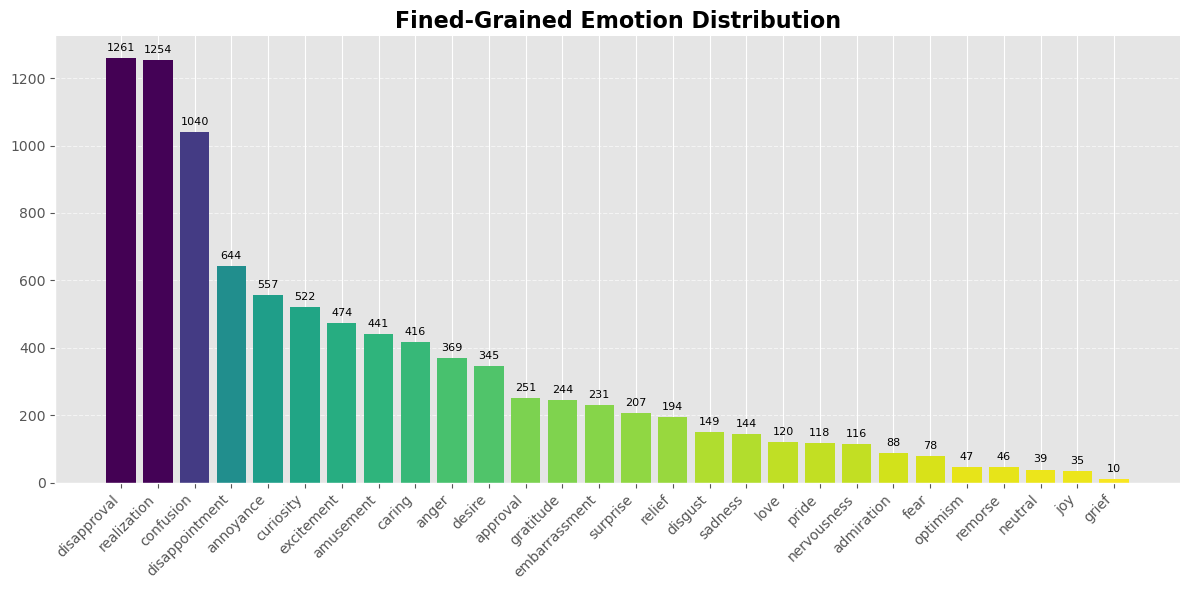

In [25]:
import matplotlib.pyplot as plt

# Count the occurrences of each emotion and sort them
emotion_counts = df['predicted_emotion'].value_counts().sort_values(ascending=False)

plt.style.use('ggplot')

plt.figure(figsize=(12, 6))

bars = plt.bar(emotion_counts.index, emotion_counts.values, color=plt.cm.viridis_r(emotion_counts.values / max(emotion_counts.values)))

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 15, f'{int(height)}', 
             ha='center', va='bottom', fontsize=8)

plt.title("Fined-Grained Emotion Distribution", fontsize=16, weight='bold')

plt.xticks(rotation=45, ha='right', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

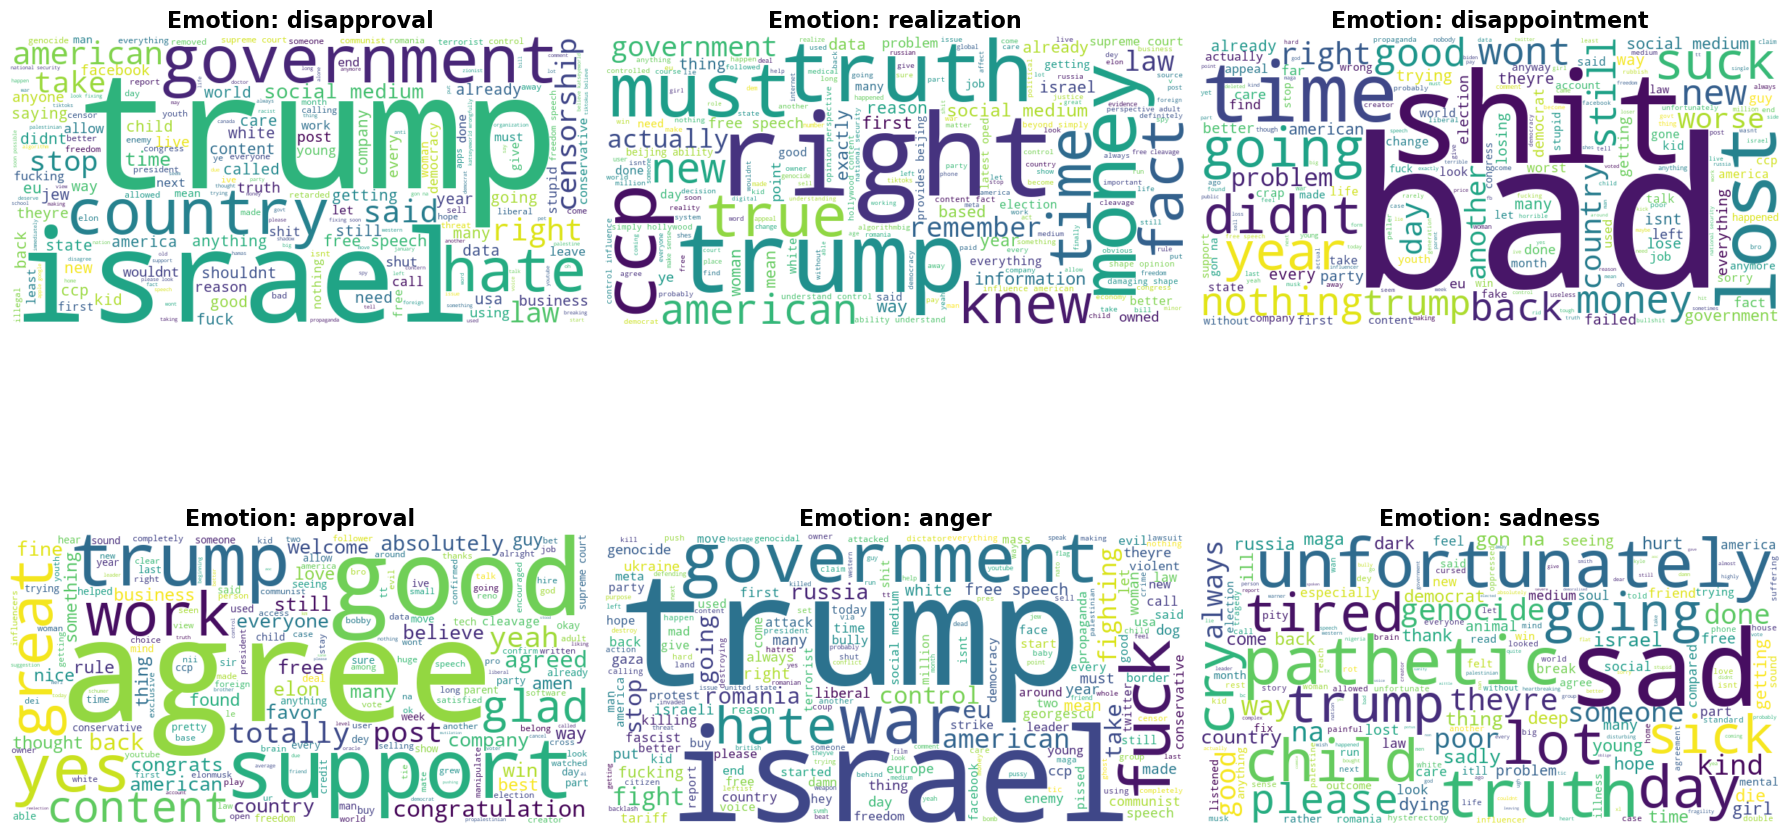

In [26]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Define custom stopwords
custom_stopwords = set(STOPWORDS)
custom_stopwords.update([
    'tiktok', 'ban','banned','banning','really','want','literally','cant','doesnt','well','think','real','dont','China','Chinese','video', 'app', 'platform', 'use', 'u', 'rt', 'http', 'https',
    'follow', 'like', 'watch', 'get', 'amp'
])

# Define the emotions to visualize
selected_emotions = ['disapproval', 'realization','disappointment', 'approval', 'anger','sadness']

plt.figure(figsize=(18, 12))

for i, emotion in enumerate(selected_emotions):
    # Get the subset of comments for the current emotion
    subset = df[df['predicted_emotion'] == emotion]['Cleaned_Comment_v2'].dropna().astype(str)
    text = " ".join(subset)

    # Generate the word cloud
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        stopwords=custom_stopwords
    ).generate(text)

    plt.subplot(2, 3, i + 1)
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f"Emotion: {emotion}", fontsize=16, weight='bold')
    plt.axis('off')

plt.tight_layout()
plt.show()


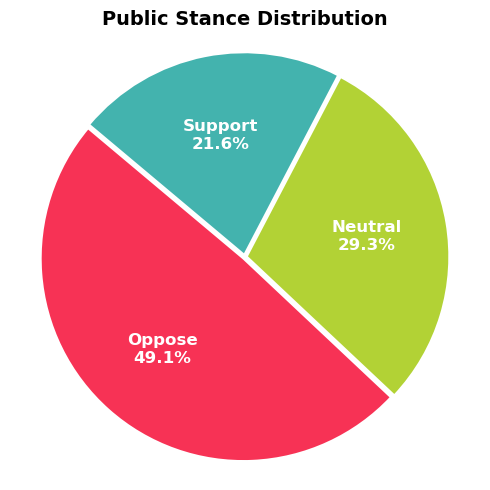

In [27]:
import matplotlib.pyplot as plt

# Define the emotions and their corresponding stance
support_emotions = ['approval', 'gratitude', 'love', 'joy', 'optimism', 'admiration','excitement','grief','amusement','pride', 'surprise']
oppose_emotions = ['disapproval', 'anger', 'annoyance', 'disappointment', 'confusion', 'disgust', 'remorse', 'fear','nervousness','sadness','embarrassment']
neutral_emotions = ['realization', 'curiosity', 'neutral', 'relief', 'desire', 'caring']

# Map emotions to stance
def map_to_stance(emotion):
    if emotion in support_emotions:
        return 'Support'
    elif emotion in oppose_emotions:
        return 'Oppose'
    else:
        return 'Neutral'

df['stance'] = df['predicted_emotion'].apply(map_to_stance)

# Count the occurrences of each stance
stance_counts = df['stance'].value_counts()

stance_color_map = {
    'Support': '#43b3ae', 
    'Oppose': '#F73255',   
    'Neutral': '#b2d235' 
}
colors = [stance_color_map[label] for label in stance_counts.index]

plt.figure(figsize=(5, 5))
wedges, texts, autotexts = plt.pie(
    stance_counts,
    labels=None, 
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    explode=[0.01] * len(stance_counts),
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)

# Customize the text labels
for i, autotext in enumerate(autotexts):
    autotext.set_color('white')
    autotext.set_fontsize(12)
    autotext.set_weight('bold')
    autotext.set_text(f"{stance_counts.index[i]}\n{autotext.get_text()}") 

plt.title("Public Stance Distribution", fontsize=14, weight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()